# **Univariable Non-Linear Regression Model + L2 Regularization**

In [1]:
%matplotlib widget

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import time
import random

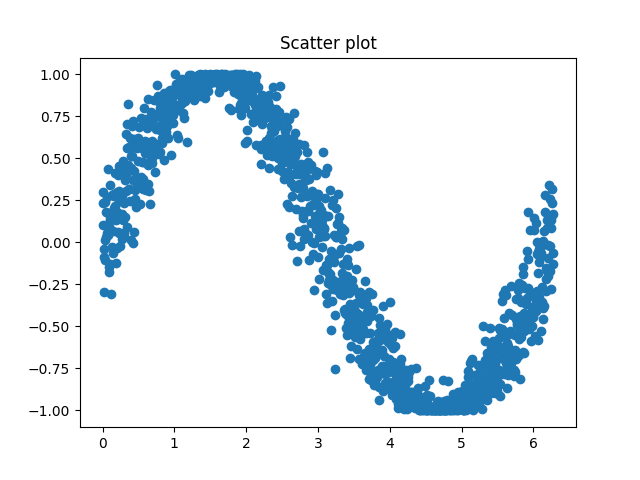

In [2]:
x = np.arange(0, 2*np.pi, 0.005)
y = np.array([np.sin(e + np.random.normal(0, 0.2)) for e in x])

# display(x.shape, y.shape)
# display(x, y)
fig = plt.figure()
plt.title("Scatter plot")
plt.scatter(x, y)

In [3]:
# NORMALIZE DATA for one feature
max_x = np.amax(x)      
min_x = np.amin(x)
    
x = np.array([(e - min_x)/(max_x - min_x) for e in x])

max_y = np.amax(y)
min_y = np.amin(y)
y = np.array([( e - min_y)/(max_y - min_y) for e in y])

# display(x.shape, y.shape)
# display(x, y)

In [4]:
# 70% for train and 30% test
m, = y.shape
idx = np.array(np.arange(m))
include_idx = set(np.random.choice(idx, size = int(0.7*m), replace=False))
mask = np.array([(i in include_idx) for i in range(m)])

trainX = x[mask]
testX = x[~mask]

trainY = y[mask]
testY = y[~mask]

# display(trainX.shape, testX.shape)
# display(trainY.shape, testY.shape)

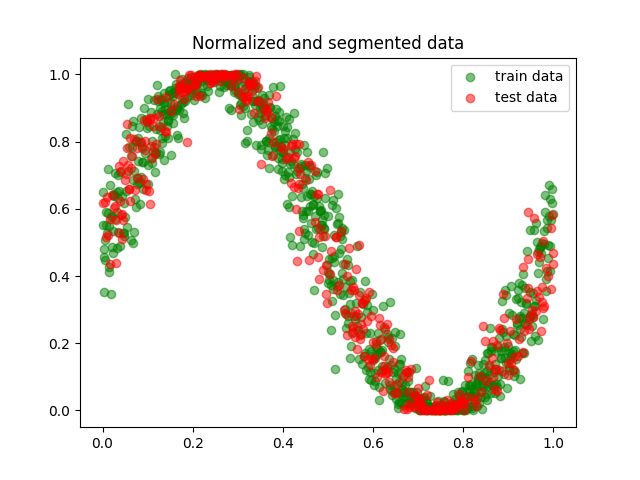

In [5]:
fig = plt.figure()
plt.title("Normalized and segmented data")
plt.scatter(trainX, trainY, color="green", alpha=0.5, label="train data")
plt.scatter(testX, testY, color="red", alpha=0.5, label="test data")
plt.legend()

In [6]:
def h(x, w):
  return np.sum(np.multiply(x, w))

In [7]:
def Error(y, x, w, lambdita):
  m, = y.shape
  e = 0
  for j in range(m):
    sum = (float(y[j] - h(x[j,:], w))**2)/(2.0*m)
    e = e + sum
  n, = w.shape
  l2 = 0
  for i in range(1, n):
    su = ((w[i]**2)/n)*(lambdita)
    l2 = l2 + su
  return e + l2

In [8]:
def derivada(x,y,w, lambdita):
  #implementar las derivadas
  m, = y.shape
  r, c = x.shape

  # first derivative
  derivatives = np.array(
    [ sum([(y[i] - h(x[i,:], w))*-1 for i in range(m)])/(m*1.0) ]
  )
  
  for j in range(1, c):
    der = sum([(y[i] - h(x[i,:], w))*-x[i, j] for i in range(m)])/(m*1.0)
    der = der + (2*w[j])*(lambdita/(m*1.0))
    derivatives = np.append(derivatives, der)
  
  return derivatives

In [9]:
def update(params, alfa, deriv):
  return params - alfa*deriv

In [10]:
arrL = []

def train(x, y, alfa, p, epochs, lambdita):
  w = np.array([np.random.rand() for i in range(p+1)])     # k+1 parametros w0 + w1x1 + ... wkxk
  
  # display(x)
  # display(w)
  i = 0
  for _ in range(epochs):
    L = Error(y, x, w, lambdita)     
    arrL.append(L)
    
    derivatives = derivada(x, y, w, lambdita)
    w = update(w ,alfa, derivatives)     
    
    if _ % 50 == 0:
      print(f"L: {L} ", end="")
    if _ % 100 == 0:
      print()
    
    # time.sleep(2)
  return w

In [11]:
def test(x, y, w, p, lambdita):
   print(f'Error: {Error(y, x, w, lambdita)}')

   # 2D PLOT
   fig = plt.figure()
   plt.title("Error function along training")
   plt.ylabel("L")
   plt.xlabel("epochs")
   plt.plot(np.arange(1,len(arrL)+1), arrL)

   # 2D FUNCTION PLOT
   xAxis = np.linspace(-0.5, 1, 100)
   yAxis = paramArr[0]
   title = str(round(paramArr[0],2))
   for i in range(1, p+1):
      yAxis += paramArr[i]*(xAxis**i)
      title += " + " + str(round(paramArr[i],2)) + f"*x^{i}"
   
   fig = plt.figure()
   plt.title("Univariable Non-Linear Regression")
   plt.scatter(trainX, trainY, color="green", alpha=0.5)
   plt.scatter(testX, testY, color="red", alpha=0.5)
   
   plt.plot(xAxis, yAxis, 'b', label=title)
   plt.legend(loc= 3, prop={'size': 5.5})

In [12]:
# EXTEND ARRAY
p = 6
epochs = 3000
alfa = 0.5 #0.08568769 # 0.0092795823740238
lambdita = 0.0234891

auxX = []
for feature in trainX:         # feature np.array int
    nRow = []
    for i in range(p+1):
        nRow.append(feature**i)
    auxX.append(nRow)
extendX = np.array(auxX)
display(extendX)

array([[1.00000000e+00, 7.96178344e-04, 6.33899955e-07, ...,
        4.01829153e-13, 3.19927670e-16, 2.54719482e-19],
       [1.00000000e+00, 1.59235669e-03, 2.53559982e-06, ...,
        6.42926645e-12, 1.02376854e-14, 1.63020469e-17],
       [1.00000000e+00, 2.38853503e-03, 5.70509960e-06, ...,
        3.25481614e-11, 7.77424238e-14, 1.85690503e-16],
       ...,
       [1.00000000e+00, 9.96019108e-01, 9.92054064e-01, ...,
        9.84171266e-01, 9.80253387e-01, 9.76351104e-01],
       [1.00000000e+00, 9.97611465e-01, 9.95228635e-01, ...,
        9.90480036e-01, 9.88114240e-01, 9.85754094e-01],
       [1.00000000e+00, 1.00000000e+00, 1.00000000e+00, ...,
        1.00000000e+00, 1.00000000e+00, 1.00000000e+00]])

In [13]:
arrL = []
paramArr = train(extendX, trainY, alfa , p, epochs, lambdita)
paramArr

L: 0.902211881833863 
L: 0.028283158038744847 L: 0.02454044924742639 
L: 0.023980243618313444 L: 0.024327845123704138 
L: 0.024882913549667887 L: 0.025459634020947135 
L: 0.026028139760428524 L: 0.026598059874155325 
L: 0.02718365253714468 L: 0.027795289400839383 
L: 0.02843873452996783 L: 0.029116258745654905 
L: 0.029827849396401568 L: 0.03057212214865949 
L: 0.03134692906603128 L: 0.032149740901757734 
L: 0.03297787899675187 L: 0.033828652031814975 
L: 0.034699434242075486 L: 0.035587708225395524 
L: 0.03649108659833489 L: 0.037407321158077905 
L: 0.03833430476436128 L: 0.03927006906279701 
L: 0.04021277990927568 L: 0.04116073159793435 
L: 0.04211234054211109 L: 0.04306613878722659 
L: 0.044020767573372054 L: 0.04497497106958388 
L: 0.04592759034501077 L: 0.04687755760869317 
L: 0.04782389073006939 L: 0.04876568804098054 
L: 0.049702123413520774 L: 0.05063244160456593 
L: 0.051555953856022844 L: 0.052472033739063756 
L: 0.05338011323041846 L: 0.05427967900894426 
L: 0.05517026896102

array([ 7.38558454e-01,  1.31760386e+00, -2.81502159e+00, -1.91126880e+00,
        1.24373259e-03,  1.60822445e+00,  1.75490917e+00])

Error: 0.07005178325484948


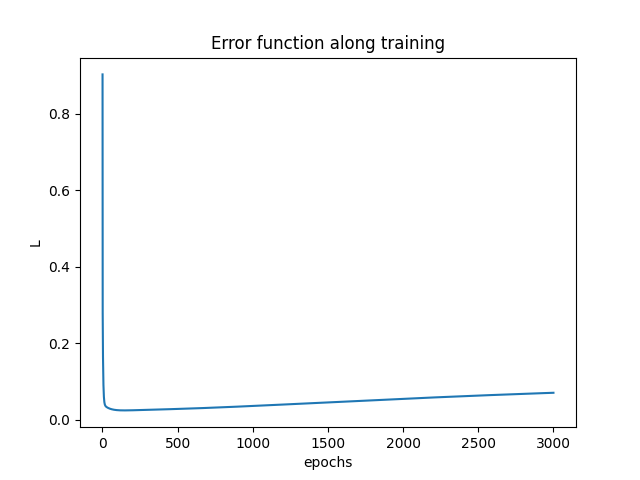

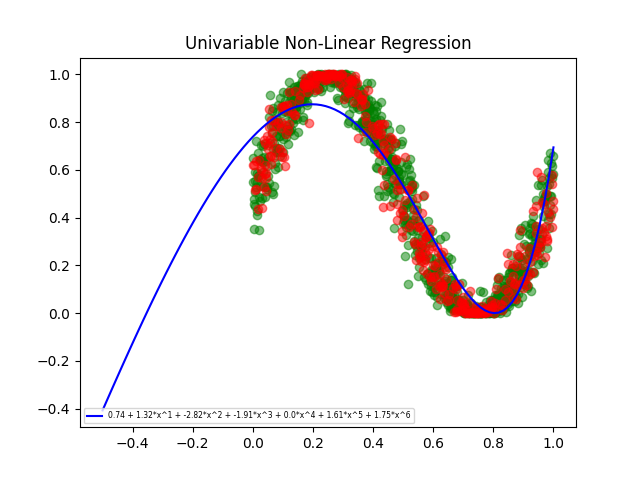

In [14]:
test(extendX, trainY, paramArr, p, lambdita)